In [16]:
from dotenv import load_dotenv
load_dotenv()

True

In [17]:
from pydantic import BaseModel
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing import Annotated

In [18]:
class ChatState(BaseModel):
    messages: Annotated[list, add_messages]

In [19]:
llm = ChatGroq(model = "openai/gpt-oss-20b")

In [20]:
def chatBotNode(state:ChatState) -> ChatState:
    res = llm.invoke(state.messages)
    state.messages = [res]
    return state

In [21]:
memory = InMemorySaver()

In [22]:
graph = StateGraph(ChatState)
graph.add_node("chatbot",chatBotNode)

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

graph = graph.compile(checkpointer = memory)

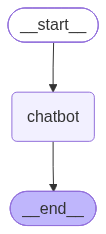

In [23]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [28]:
res = graph.invoke({"messages":[{"role":"user", "content":"What is my name"},
]},
{"configurable":{"thread_id": "My graph bot"}}
)

In [29]:
res["messages"][-1].content

'You’re Vineet\u202fSharma.'